# Data Preprocessing Template for ACE6313 Assignment
## Part A: Data Preprocessing
### Member 1 - Data Preprocessing Tasks

This notebook provides a structured template for completing the data preprocessing portion of the assignment. It covers:
1. **Data Cleaning** - Handling missing values, duplicates, inconsistencies, and outliers
2. **Data Transformation** - Feature scaling, categorical encoding, and feature engineering
3. **Data Reduction** - Feature selection, extraction, or dimensionality reduction

**Dataset**: StudentPerformanceFactors.csv (6,607 rows, 20 columns)
**Target Variable**: Exam_Score (continuous regression task)
**SDG Alignment**: SDG 4: Quality Education


In [229]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)

# Set random seed for reproducibility
np.random.seed(42)


## 1. Data Loading and Initial Exploration


In [230]:
# Load the dataset
df = pd.read_csv('data/StudentPerformanceFactors.csv')

# Display basic information
print('Dataset Shape:', df.shape)
print('Column Names:', df.columns.tolist())
print("Data Types:")
print(df.dtypes)

# Display first few rows
print("First 5 rows:")
print(df.head())

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Basic statistics
print("Basic Statistics:")
print(df.describe())

Dataset Shape: (6607, 20)
Column Names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
Data Types:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabil

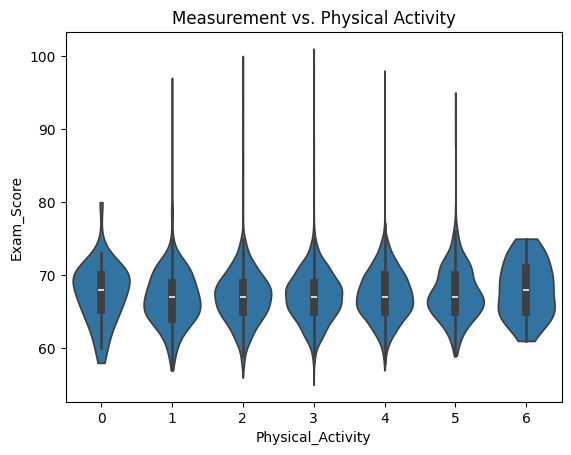

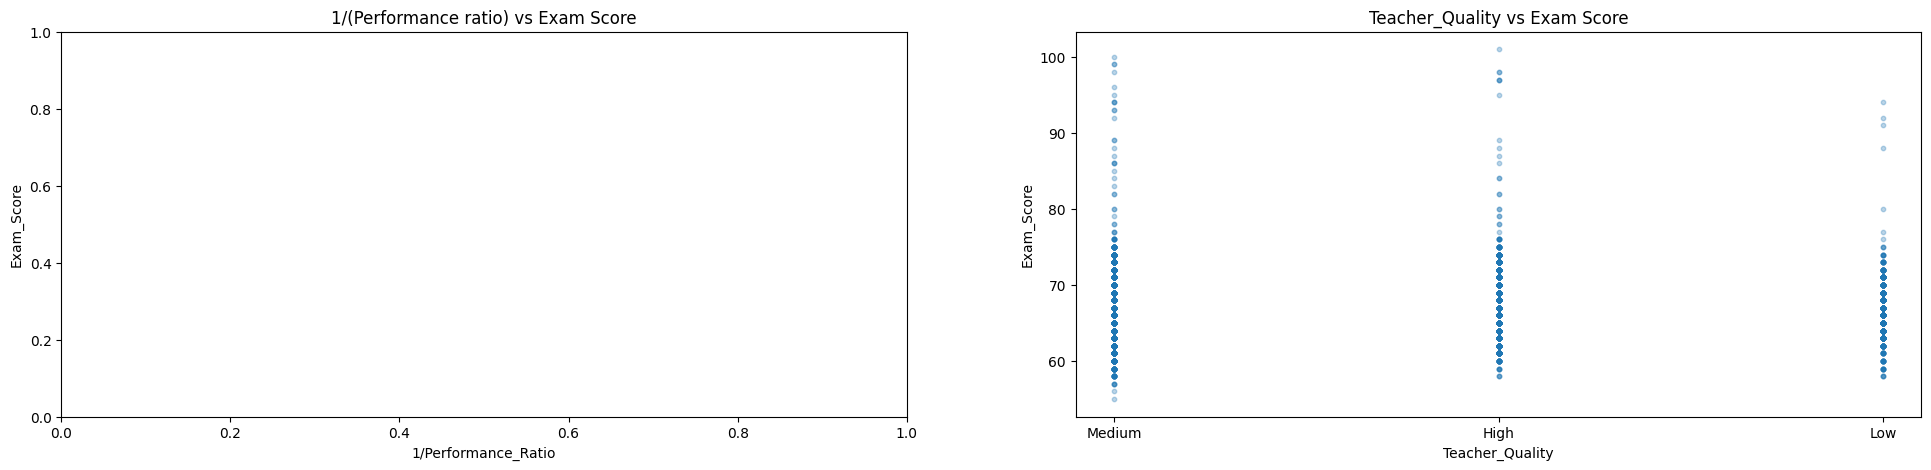

In [ ]:
sns.violinplot(
    x='Physical_Activity',
    y='Exam_Score',
    data=df,
    order=sorted(df['Physical_Activity'].unique()),
    inner='box',
    cut=0,
    scale='width'
)

plt.title('Exam Score vs. Physical Activity')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 5))
# ax1.violinplot(collection)
ax1.set(xlabel='1/Performance_Ratio', ylabel='Exam_Score', title='1/(Performance ratio) vs Exam Score')
ax2.scatter(df['Teacher_Quality'], df['Exam_Score'], alpha=0.3, s=10)
ax2.set(xlabel='Teacher_Quality', ylabel='Exam_Score', title='Teacher_Quality vs Exam Score')
# plt.tight_layout()
plt.show()

## 2. Data Cleaning (A1)


### A1.1 Handle Missing Values


In [231]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

print('Missing Values Analysis:')
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Strategy for handling missing values
# For numeric columns: fill with median
# For categorical columns: fill with mode

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])


print("Missing values after handling:")
print(df.isnull().sum().sum(), ' total missing values remaining')

Missing Values Analysis:
                      Column  Missing_Count  Missing_Percentage
16  Parental_Education_Level             90            1.362192
11           Teacher_Quality             78            1.180566
17        Distance_from_Home             67            1.014076
Missing values after handling:
0  total missing values remaining


### A1.2 Remove or Flag Duplicates


In [232]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_rows}')

# Remove duplicates
# df.drop_duplicates(inplace=True)

# print(f'Dataset shape after removing duplicates: {df.shape}')

Number of duplicate rows: 0


### A1.3 Identify and Address Inconsistencies and Outliers


In [233]:
# Check for inconsistencies in categorical columns
print('Checking for inconsistencies in categorical columns:')
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f'{col}: {len(unique_values)} unique values - {unique_values}')

# Check for outliers in numeric columns using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers for key numeric columns
key_numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']
for col in key_numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f'{col}: {len(outliers)} outliers detected (bounds: {lower:.2f} - {upper:.2f})')

# Strategy for handling outliers
# Option 1: Remove outliers
# Option 2: Cap outliers at bounds
# Option 3: Use robust scaling methods

# Example: Cap outliers at 1.5 * IQR
for col in key_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

Checking for inconsistencies in categorical columns:
Parental_Involvement: 3 unique values - <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources: 3 unique values - <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities: 2 unique values - <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level: 3 unique values - <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access: 2 unique values - <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income: 3 unique values - <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality: 3 unique values - <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
School_Type: 2 unique values - <StringArray>
['Public', 'Private']
Length: 2, dtype: str
Peer_Influence: 3 unique values - <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
Learning_Disabilities: 2 unique values - <StringArray>
['No', 'Yes']
Length: 2

## 3. Data Transformation (A2)


In [234]:
# Separate features and target
X = df.drop('Exam_Score', axis=1)
display(X)
y = df['Exam_Score']

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


### A2.3 Feature Engineering (Optional)


In [410]:
# Feature engineering examples
# Create a copy for feature engineering
X_fe = X.copy()


# Example 1: Create performance ratio feature
X_fe['Performance_Ratio'] = X_fe['Previous_Scores'] / (X_fe['Hours_Studied'] + 1)

# Example 2: Create attendance efficiency feature
X_fe['Attendance_Efficiency'] = X_fe['Attendance'] * (X_fe['Sleep_Hours'] / 8)

# Example 3: Create tutoring effectiveness feature
X_fe['Tutoring_Effectiveness'] = X_fe['Tutoring_Sessions'] / (X_fe['Hours_Studied'] + 1)

# Example 4: Create family support index
# Create a composite score for family support
family_support_cols = ['Parental_Involvement', 'Access_to_Resources', 'Family_Income']
# For demonstration, we'll use a simple approach
X_fe['Family_Support_Index'] = (X_fe['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3}) +
                                   X_fe['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3}) +
                                   X_fe['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3})) / 3

X_fe['Wellbeing_Index'] = (     #(X_fe['Previous_Scores']/X_fe['Previous_Scores'].max()) +
                                X_fe['Extracurricular_Activities'].map({'No': 0, 'Yes': 1}) +
                                X_fe['Motivation_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})/3 +
                                ((X_fe['Physical_Activity'])/X_fe['Physical_Activity'].max()) +
                                X_fe['Peer_Influence'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})
                                ) / 4
X_fe['Academic_Support_Index'] = (
    (X_fe['Tutoring_Sessions'] / X_fe['Tutoring_Sessions'].max()) +
    X_fe['School_Type'].map({'Public': 0, 'Private': 1}) +
    X_fe['Internet_Access'].map({'No': 0, 'Yes': 1})
) / 3

print('Feature engineering completed')
print(f'Final feature count: {X_fe.shape[1]}')
X_encoded = X_fe

display(X_fe)

Feature engineering completed
Final feature count: 25


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Ratio,Attendance_Efficiency,Tutoring_Effectiveness,Family_Support_Index,Wellbeing_Index,Academic_Support_Index
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,3.041667,73.500,0.000000,1.666667,0.458333,0.333333
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,2.950000,64.000,0.100000,1.666667,0.000000,0.416667
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,3.640000,85.750,0.080000,2.000000,0.583333,0.416667
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,3.266667,89.000,0.033333,1.666667,0.333333,0.375000
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,3.250000,69.000,0.150000,2.000000,0.583333,0.458333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,2.923077,60.375,0.038462,2.666667,0.500000,0.375000
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,3.375000,76.000,0.125000,2.000000,0.500000,0.458333
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,3.095238,67.500,0.142857,1.333333,0.166667,0.458333
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,8.272727,64.500,0.181818,2.333333,0.875000,0.750000


### A2.1 Feature Scaling


In [411]:
# Identify numeric and categorical columns for scaling
numeric_features = X_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_fe.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features to scale: {numeric_features}')
print(f'Categorical features: {categorical_features}')

# Apply StandardScaler to numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_fe[numeric_features])

print('Feature scaling completed using StandardScaler')

# Alternative: MinMaxScaler
# scaler = MinMaxScaler()
# X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

Numeric features to scale: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Performance_Ratio', 'Attendance_Efficiency', 'Tutoring_Effectiveness', 'Family_Support_Index', 'Wellbeing_Index', 'Academic_Support_Index']
Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Feature scaling completed using StandardScaler


### A2.2 Encoding of Categorical Variables


In [412]:
# Create a copy for encoding
X_encoded = X_scaled.copy()

# Method 1: One-Hot Encoding for high cardinality categorical variables
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X_encoded, columns=categorical_features, drop_first=True)

print(f'Original shape: {X.shape}')
print(f'Encoded shape: {X_encoded.shape}')
print(f'Number of new features created: {X_encoded.shape[1] - X.shape[1]}')

# Method 2: Label Encoding for low cardinality (alternative)
# label_encoders = {}
# for col in categorical_features:
#     le = LabelEncoder()
#     X_encoded[col] = le.fit_transform(X_encoded[col])
#     label_encoders[col] = le

display(X_encoded.columns)

Original shape: (6607, 19)
Encoded shape: (6607, 33)
Number of new features created: 14


Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Performance_Ratio',
       'Attendance_Efficiency', 'Tutoring_Effectiveness',
       'Family_Support_Index', 'Wellbeing_Index', 'Academic_Support_Index',
       'Parental_Involvement_Low', 'Parental_Involvement_Medium',
       'Access_to_Resources_Low', 'Access_to_Resources_Medium',
       'Extracurricular_Activities_Yes', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low',
       'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'School_Type_Public', 'Peer_Influence_Neutral',
       'Peer_Influence_Positive', 'Learning_Disabilities_Yes',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near', 'Gender_Male'],
      dtype='str')

## 4. Data Reduction (A3)


### A3.1 Feature Selection using Correlation Analysis


In [413]:
# Calculate correlation matrix
correlation_matrix = pd.concat([X_encoded, y], axis=1).corr()

# Get correlation with target variable
target_correlation = correlation_matrix['Exam_Score'].abs().sort_values(ascending=False)
target_correlation.pop('Exam_Score')
print('Top 15 features correlated with Exam_Score:')
print(target_correlation.head(15))

# Select features with correlation > 0.05 (adjust threshold as needed)
threshold = 0.05
selected_features = target_correlation[target_correlation > threshold].index.tolist()

print(f'Selected {len(selected_features)} features with correlation > {threshold}:')
print(selected_features)

# Create reduced dataset
X_reduced = X_encoded[selected_features].copy()

print(f'Reduced dataset shape: {X_reduced.shape}')

Top 15 features correlated with Exam_Score:
Attendance                               0.581072
Hours_Studied                            0.445387
Attendance_Efficiency                    0.314247
Performance_Ratio                        0.268221
Family_Support_Index                     0.242911
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Wellbeing_Index                          0.139095
Access_to_Resources_Low                  0.132155
Parental_Involvement_Low                 0.113602
Parental_Education_Level_Postgraduate    0.093764
Parental_Education_Level_High School     0.087054
Learning_Disabilities_Yes                0.085066
Family_Income_Low                        0.082025
Peer_Influence_Positive                  0.081217
Name: Exam_Score, dtype: float64
Selected 20 features with correlation > 0.05:
['Attendance', 'Hours_Studied', 'Attendance_Efficiency', 'Performance_Ratio', 'Family_Support_Index', 'Previous_Scores', 'Tutor

### A3.2 Alternative: Feature Importance using Random Forest


In [414]:
# Alternative feature selection using Random Forest feature importance
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest to get feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print('Top 10 most important features:')
print(feature_importance.head(10))

# Select top 15 features
n_features = 15
selected_features_rf = feature_importance.head(n_features)['Feature'].tolist()

X_reduced_rf = X_encoded[selected_features_rf].copy()

print(f'Selected {len(selected_features_rf)} features using Random Forest importance')
print(f'Reduced dataset shape: {X_reduced_rf.shape}')

Top 10 most important features:
                   Feature  Importance
1               Attendance    0.366509
0            Hours_Studied    0.224178
9     Family_Support_Index    0.072119
3          Previous_Scores    0.061674
10         Wellbeing_Index    0.043482
6        Performance_Ratio    0.036704
7    Attendance_Efficiency    0.029374
11  Academic_Support_Index    0.024814
8   Tutoring_Effectiveness    0.024465
5        Physical_Activity    0.017581
Selected 15 features using Random Forest importance
Reduced dataset shape: (6607, 15)


### A3.3 Dimensionality Reduction using PCA


In [415]:
# Alternative: Dimensionality reduction using PCA
from sklearn.decomposition import PCA

# Apply PCA to select components explaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_encoded)

print(f'Original number of features: {X_encoded.shape[1]}')
print(f'Number of PCA components needed for 95% variance: {pca.n_components_}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}')

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(pca.n_components_)])


Original number of features: 33
Number of PCA components needed for 95% variance: 20
Explained variance ratio: 0.96


## 5. Final Preprocessing Pipeline


In [416]:
# Create final preprocessed dataset
# Choose one of the following approaches based on your preference:

missing_before = df.isnull().sum().copy()  # save snapshot before cleaning

# Option 1: Use correlation-based feature selection
final_features = selected_features
X_final = X_reduced

# Option 2: Use Random Forest feature importance
# final_features = selected_features_rf
# X_final = X_reduced_rf

# Option 3: Use PCA
# X_final = pca_df
# final_features = [f'PC{i+1}' for i in range(pca.n_components_)]

print('=== FINAL PREPROCESSING SUMMARY ===')
print(f'Original features: {X.shape[1]}')
print(f'Final features: {X_final.shape[1]}')
print(f'Feature reduction: {X.shape[1] - X_final.shape[1]} features removed')
print(f'Final dataset shape: {X_final.shape}')

# Save preprocessed data
# X_final.to_csv('data/X_preprocessed.csv', index=False)
# y.to_csv('data/y_preprocessed.csv', index=False)

print('Preprocessing pipeline completed successfully!')

=== FINAL PREPROCESSING SUMMARY ===
Original features: 19
Final features: 20
Feature reduction: -1 features removed
Final dataset shape: (6607, 20)
Preprocessing pipeline completed successfully!


## 6. Visualization and Documentation


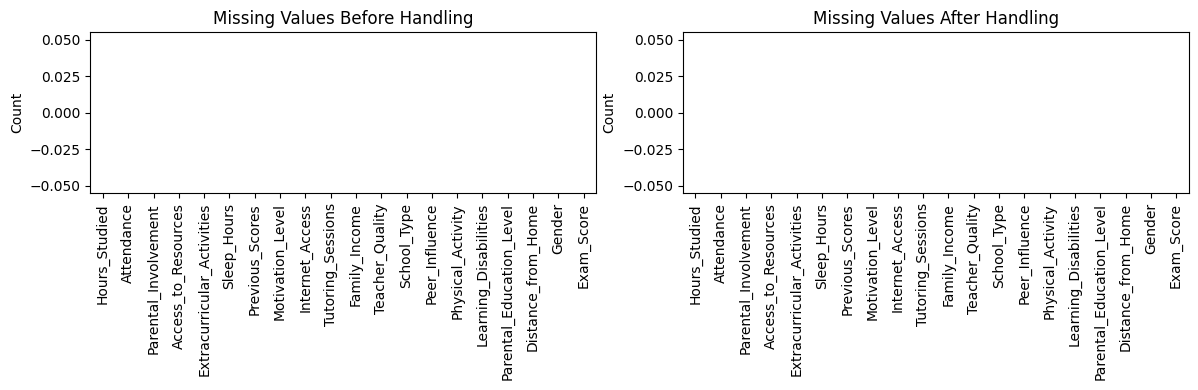

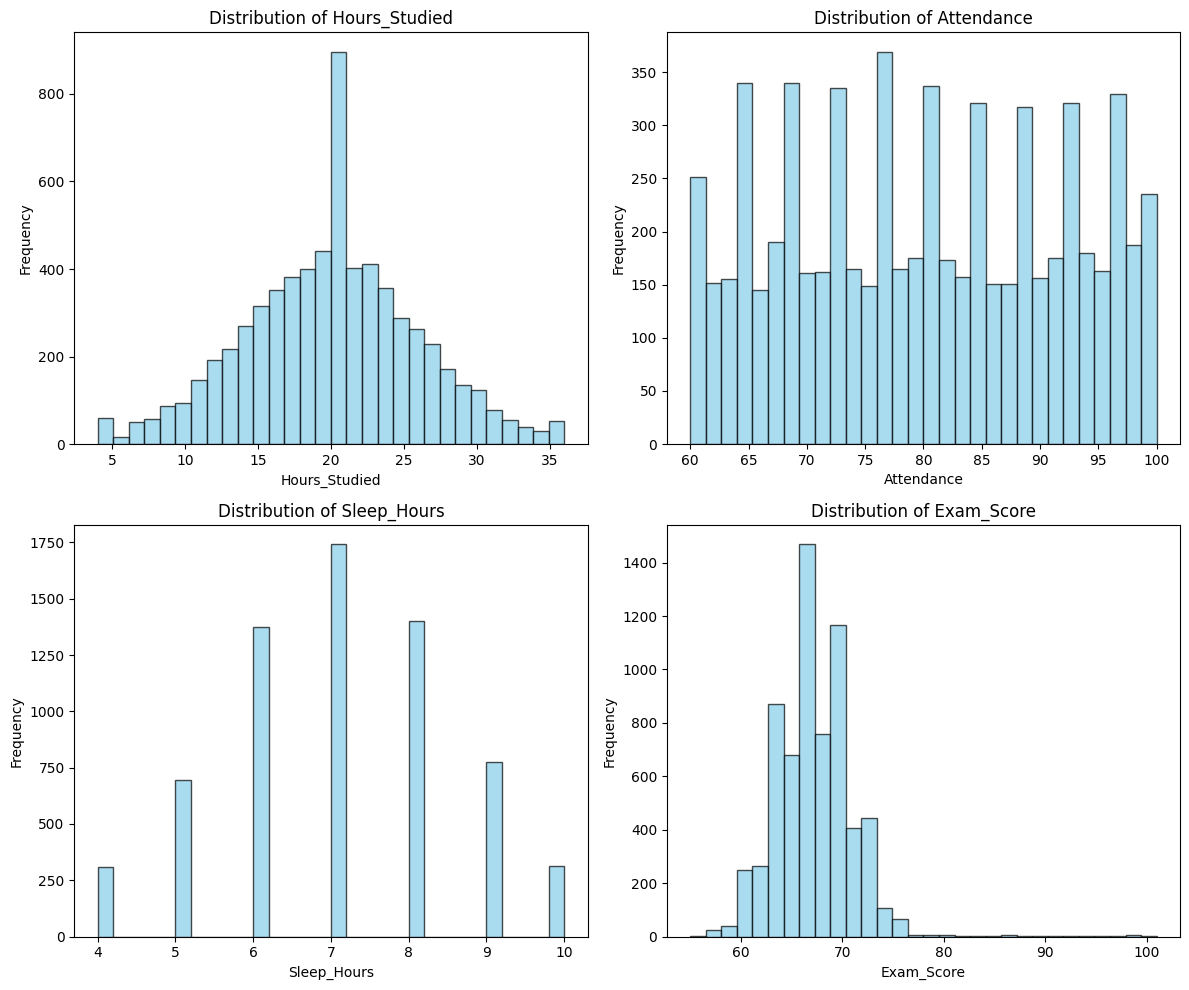

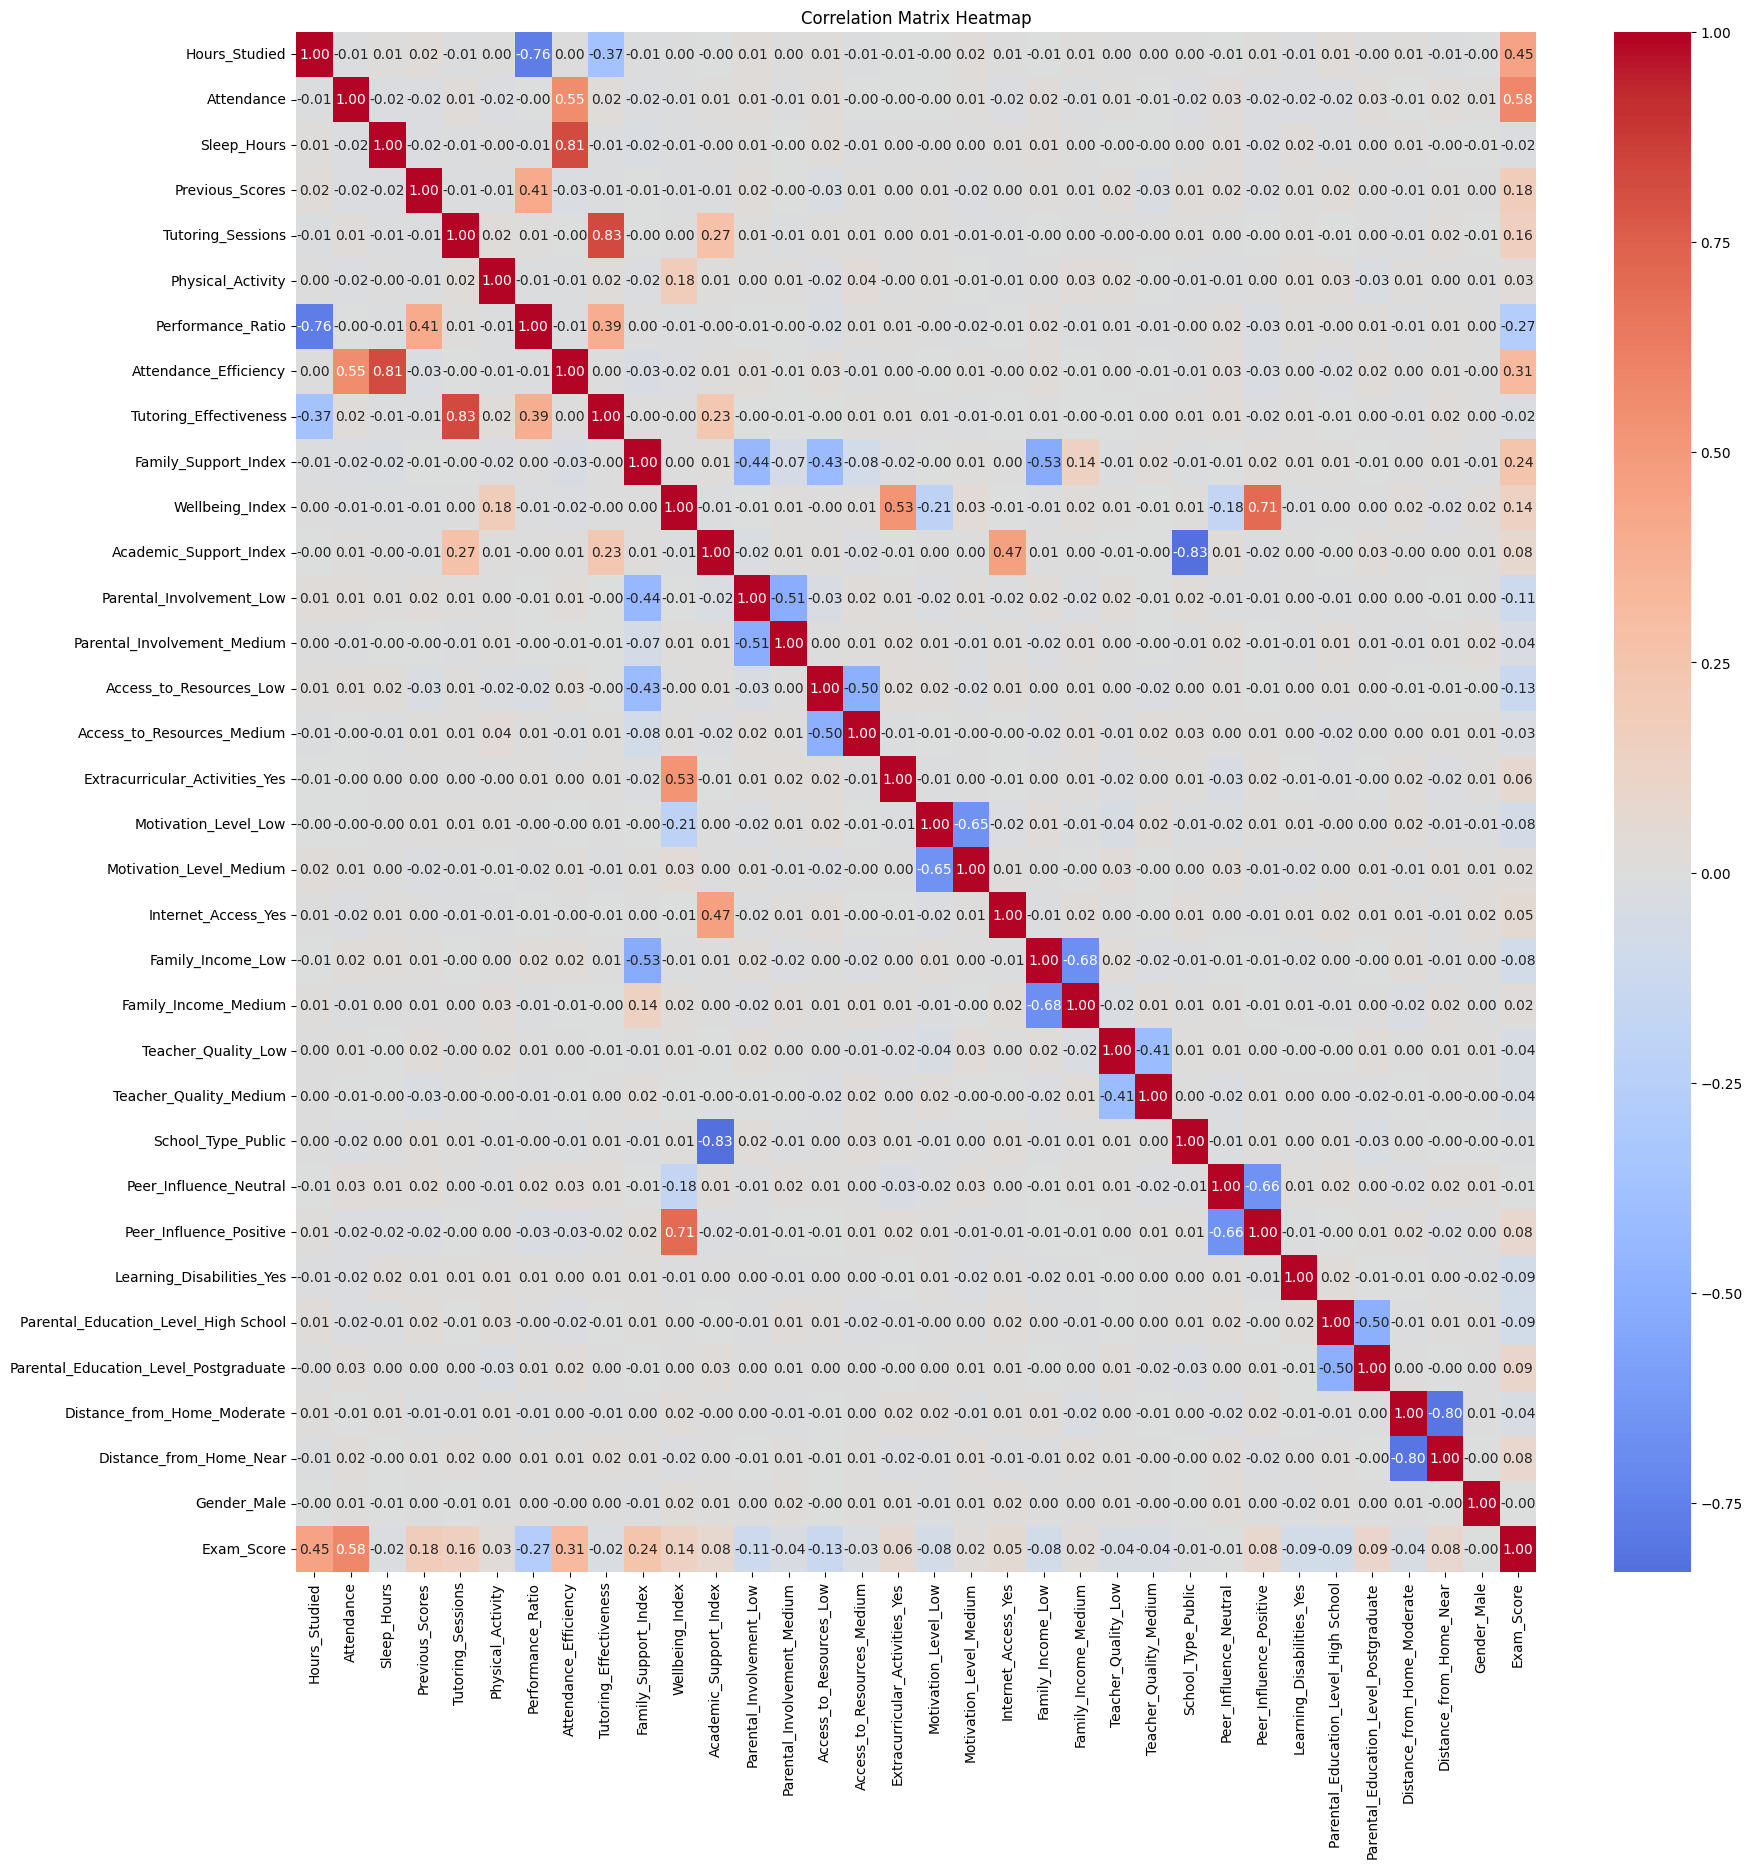

Visualizations completed for documentation


In [417]:
# Create visualizations for documentation

# 1. Missing values before and after handling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Before handling (simulated)
missing_before = df.isnull().sum()
missing_before.plot(kind='bar', ax=ax1, title='Missing Values Before Handling')
ax1.set_ylabel('Count')

# After handling
missing_after = df.isnull().sum()
missing_after.plot(kind='bar', ax=ax2, title='Missing Values After Handling')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

# 2. Distribution of key numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features_to_plot = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Exam_Score']

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 2, idx % 2
    axes[row, col].hist(df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

print('Visualizations completed for documentation')

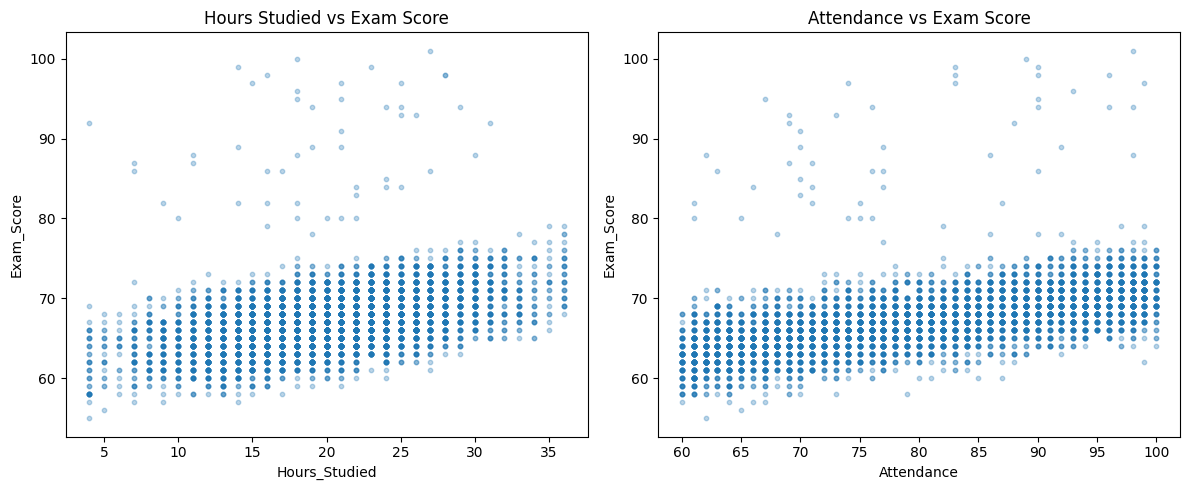

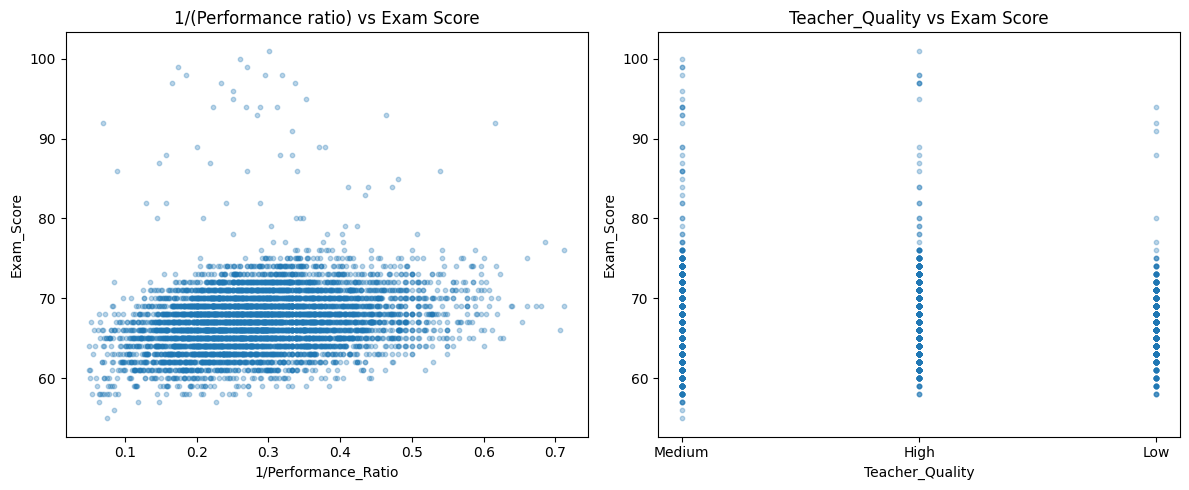

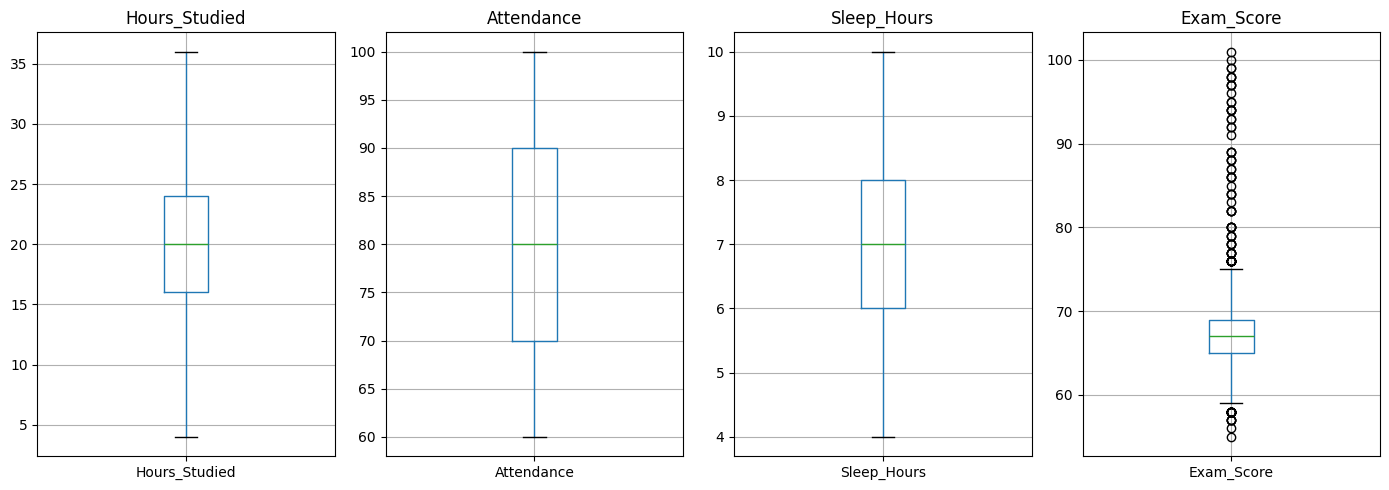

In [418]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.3, s=10)
ax1.set(xlabel='Hours_Studied', ylabel='Exam_Score', title='Hours Studied vs Exam Score')
ax2.scatter(df['Attendance'], df['Exam_Score'], alpha=0.3, s=10)
ax2.set(xlabel='Attendance', ylabel='Exam_Score', title='Attendance vs Exam Score')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(1/(X_fe['Performance_Ratio']), df['Exam_Score'], alpha=0.3, s=10)
ax1.set(xlabel='1/Performance_Ratio', ylabel='Exam_Score', title='1/(Performance ratio) vs Exam Score')
ax2.scatter(df['Teacher_Quality'], df['Exam_Score'], alpha=0.3, s=10)
ax2.set(xlabel='Teacher_Quality', ylabel='Exam_Score', title='Teacher_Quality vs Exam Score')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, col in zip(axes, ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Exam_Score']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 7. Next Steps

1. **Save the preprocessed data**: Uncomment the save lines in the final preprocessing section
2. **Document your methodology**: Record the decisions made in each preprocessing step
3. **Create README**: Document the preprocessing pipeline for your GitHub repository
4. **Proceed to Part B**: Share the preprocessed data with Member 2 for model building

**Important Notes**:
- This template is a starting point - adapt it to your specific needs
- Ensure you document all preprocessing decisions for the final report
- Consider cross-validation strategies when evaluating preprocessing steps
- Keep track of data leakage prevention throughout the pipeline
